# Puget Sound Hypoxia Analysis: Apparent Oxygen Utilization (AOU)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import linregress


output_dir = "generated_figures"
os.makedirs(output_dir, exist_ok=True)s

def save_fig(fig, name):
    fig.savefig(os.path.join(output_dir, f"{name}.png"), dpi=300, bbox_inches='tight')
    plt.close(fig)

SyntaxError: invalid syntax (1102161993.py, line 10)

In [ ]:
regions = ['Liplip Kinney', 'Lynch Cove', 'Penn Cove', 'Holmes Harbor']

def load_profiles(var, region):
    fname = f"daily_profiles_csv/{var}_{region}.csv"
    df = pd.read_csv(fname, index_col='date', parse_dates=True)
    return df

DO_profiles = {r: load_profiles("DO", r) for r in regions}
T_profiles  = {r: load_profiles("temperature", r) for r in regions}
S_profiles  = {r: load_profiles("salinity", r) for r in regions}
depth = np.loadtxt("depth_levels.txt")

NameError: name 'pd' is not defined

In [3]:
def oxygen_saturation(T, S):
    # T en °C, S en PSU
    Tk = T + 273.15

    A0 = 5.80818
    A1 = 3.20684
    A2 = 4.11890
    A3 = 4.93845
    A4 = 1.01567
    A5 = 1.41575

    B0 = -7.01211e-3
    B1 = -7.25958e-3
    B2 = -7.93334e-3
    B3 = -5.54491e-3

    C0 = -1.32412e-7

    Ts = np.log((298.15 - T) / Tk)

    lnO2 = (A0 + A1*Ts + A2*Ts**2 + A3*Ts**3 +
            A4*Ts**4 + A5*Ts**5 +
            S*(B0 + B1*Ts + B2*Ts**2 + B3*Ts**3) +
            C0*S**2)

    return np.exp(lnO2) * 1.42903  # mmol/m3

In [4]:
O2sat_all = np.concatenate([
    oxygen_saturation(T_profiles[r], S_profiles[r]).values.flatten()
    for r in regions
])

O2sat_mean = np.nanmean(O2sat_all)
print(O2sat_mean)

408.3980191953901


In [5]:
region_labels = {
    'Lynch Cove': 'LC',
    'Penn Cove': 'PC',
    'Holmes Harbor': 'HH',
    'Liplip Kinney': 'LK'
}

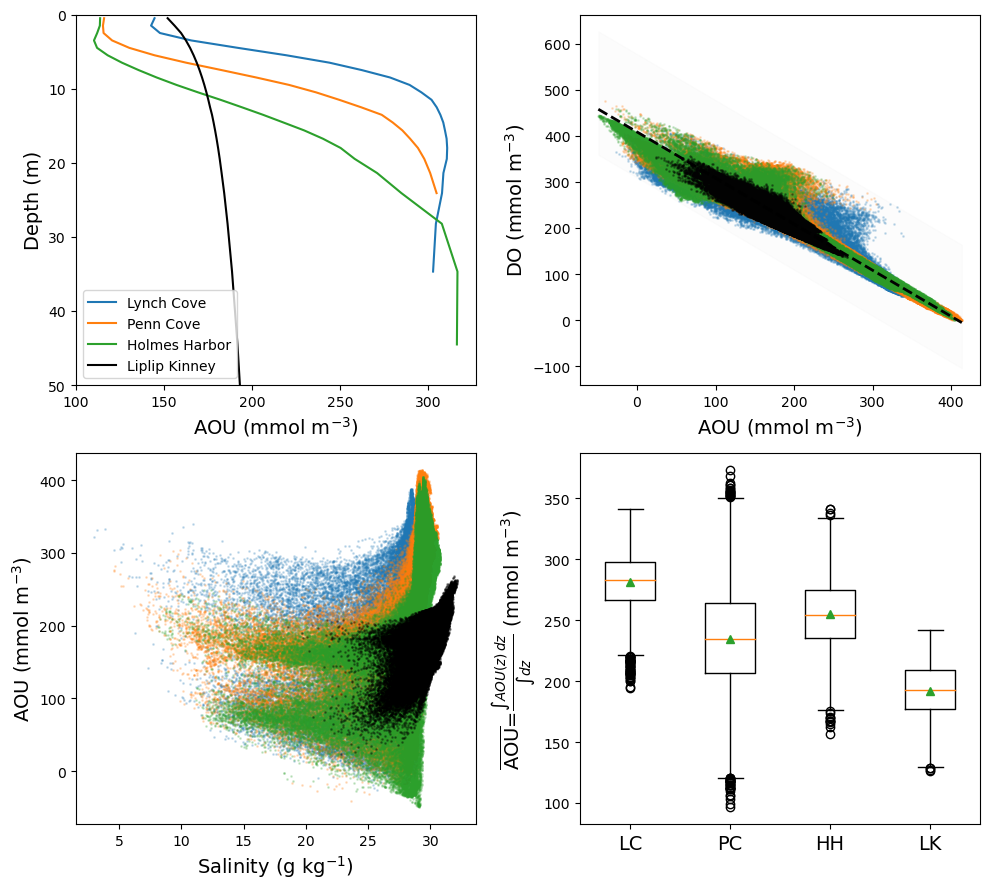

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10,9))
dz = np.gradient(depth)

first_region = regions[0]
other_regions = regions[1:]


AOU_all = np.concatenate([
    (oxygen_saturation(T_profiles[r], S_profiles[r]) - DO_profiles[r]).values.flatten()
    for r in regions
])

O2sat_all = np.concatenate([
    oxygen_saturation(T_profiles[r], S_profiles[r]).values.flatten()
    for r in regions
])

AOU_min = np.nanmin(AOU_all)
AOU_max = np.nanmax(AOU_all)

x = np.linspace(AOU_min, AOU_max, 100)

O2sat_mean = np.nanmean(O2sat_all)
y = O2sat_mean - x

O2sat_min = np.nanmin(O2sat_all)
O2sat_max = np.nanmax(O2sat_all)

y_min = O2sat_min - x
y_max = O2sat_max - x

for i, r in enumerate(other_regions):
    DO = DO_profiles[r]
    T  = T_profiles[r]
    S  = S_profiles[r]

    O2sat = oxygen_saturation(T, S)
    AOU = O2sat - DO

    mean_AOU = AOU.mean(axis=0)
    axes[0,0].plot(mean_AOU, depth, label=r)

    DO_flat = DO.values.flatten()
    AOU_flat = AOU.values.flatten()
    mask = ~np.isnan(DO_flat) & ~np.isnan(AOU_flat)

    axes[0,1].scatter(AOU_flat[mask], DO_flat[mask],
                      s=1, alpha=0.2, label=r)

    sal = S.values.flatten()
    axes[1,0].scatter(sal[mask], AOU_flat[mask],
                      s=1, alpha=0.2, label=r)

    valid_mask = ~np.isnan(AOU)
    AOU_int = (AOU * dz).where(valid_mask).sum(axis=1)
    thickness = (dz * valid_mask).sum(axis=1)
    AOU_mean = AOU_int / thickness
    axes[1,1].boxplot(AOU_mean.dropna(), positions=[i], showmeans=True, widths=0.5)

# Plot for the first region with distinction
r = first_region
DO = DO_profiles[r]
T  = T_profiles[r]
S  = S_profiles[r]

O2sat = oxygen_saturation(T, S)
AOU = O2sat - DO

mean_AOU = AOU.mean(axis=0)
axes[0,0].plot(mean_AOU, depth, label=r, color='black')

DO_flat = DO.values.flatten()
AOU_flat = AOU.values.flatten()
mask = ~np.isnan(DO_flat) & ~np.isnan(AOU_flat)

axes[0,1].scatter(AOU_flat[mask], DO_flat[mask],
                  s=1, alpha=0.3, color='black', label=r)

sal = S.values.flatten()
axes[1,0].scatter(sal[mask], AOU_flat[mask],
                  s=1, alpha=0.3, color='black', label=r)

valid_mask = ~np.isnan(AOU)
AOU_int = (AOU * dz).where(valid_mask).sum(axis=1)
thickness = (dz * valid_mask).sum(axis=1)
AOU_mean = AOU_int / thickness
axes[1,1].boxplot(AOU_mean.dropna(), positions=[len(regions)-1],
                  showmeans=True, widths=0.5)

# Theoretical line for DO = O2sat - AOU
axes[0,1].plot(x, y, 'k--', linewidth=2,
               label='DO = O$_2^{sat}$ - AOU')

axes[0,1].fill_between(x, y_min, y_max,
                       color='gray', alpha=0.02,
                       label='O$_2^{sat}$ range')

# 
axes[0,0].invert_yaxis()
axes[0,0].set_ylim(50, 0)
axes[0,0].set_ylabel("Depth (m)", fontsize=14)
axes[0,0].set_xlabel("AOU (mmol m$^{-3}$)", fontsize=14)
axes[0,0].legend()

axes[0,1].set_xlabel("AOU (mmol m$^{-3}$)", fontsize=14)
axes[0,1].set_ylabel("DO (mmol m$^{-3}$)", fontsize=14)

axes[1,0].set_xlabel("Salinity (g kg$^{-1}$)", fontsize=14)
axes[1,0].set_ylabel("AOU (mmol m$^{-3}$)", fontsize=14)

plot_order = other_regions + [first_region]

axes[1,1].set_xticks(range(len(plot_order)))
axes[1,1].set_xticklabels([region_labels[r] for r in plot_order], fontsize=14)
axes[1,1].set_ylabel(r'$\overline{\mathrm{AOU}}$=$\frac{\int AOU(z)\,dz}{\int dz}$ (mmol m$^{-3}$)', fontsize=14)

plt.tight_layout()
plt.show()

save_fig(fig, "AOU_profiles_and_relationships")

In [7]:
def compute_bottom_DO(DO_profiles, n_levels=3):
    return {
        r: compute_bottom_variable(DO_profiles[r], n_levels=n_levels)
        for r in DO_profiles
    }

In [8]:
def compute_bottom_variable(X, n_levels=3):

    X_bottom = []

    for t in range(len(X)):
        profile = X.iloc[t].values
        valid = ~np.isnan(profile)

        if valid.sum() < n_levels:
            X_bottom.append(np.nan)
            continue

        idx = np.where(valid)[0]
        bottom_idx = idx[-n_levels:]

        X_bottom.append(np.mean(profile[bottom_idx]))

    return pd.Series(X_bottom, index=X.index)

In [9]:
def compute_daily_climatology(ts):
    df = pd.DataFrame({"DO": ts})
    df["doy"] = df.index.dayofyear

    clim = df.groupby("doy")["DO"].agg(np.nanmean)
    std = df.groupby("doy")["DO"].agg(np.nanstd)

    return clim, std

In [10]:
# choose ONE:
DO_timeseries = compute_bottom_DO(DO_profiles)
# DO_timeseries = compute_mean_DO(DO_profiles)

clim = {}
spread = {}

for r in DO_timeseries:
    clim[r], spread[r] = compute_daily_climatology(DO_timeseries[r])

/tmp/ipykernel_3506179/413769662.py:5: FutureWarning: The provided callable <function nanmean at 0x7f85781c54e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  clim = df.groupby("doy")["DO"].agg(np.nanmean)
/tmp/ipykernel_3506179/413769662.py:6: FutureWarning: The provided callable <function nanstd at 0x7f85781c5ee0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  std = df.groupby("doy")["DO"].agg(np.nanstd)
/tmp/ipykernel_3506179/413769662.py:5: FutureWarning: The provided callable <function nanmean at 0x7f85781c54e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  clim = df.groupby("doy")["DO"].agg(np.nanmean)
/tm

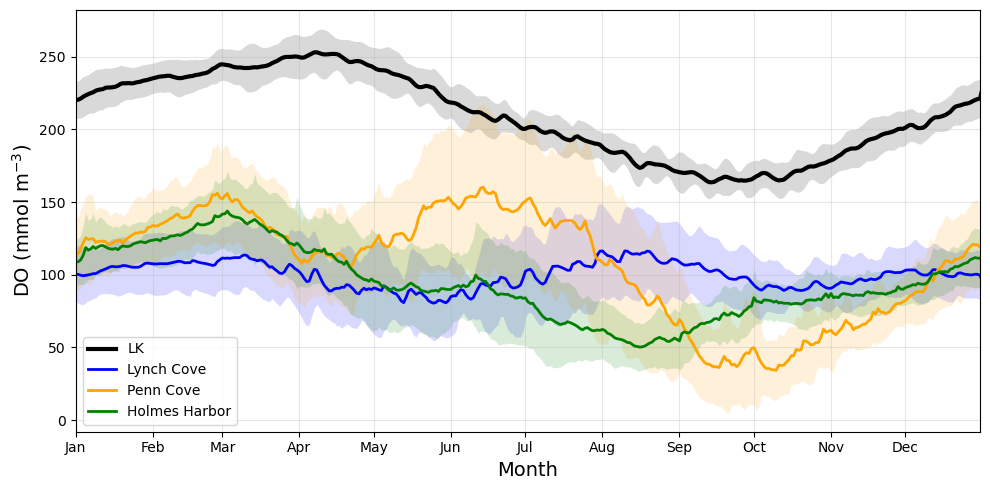

In [11]:
fig = plt.figure(figsize=(10,5))

days = np.arange(1, 367)

colors = {
    "Liplip Kinney": "black",
    "Lynch Cove": "blue",
    "Penn Cove": "orange",
    "Holmes Harbor": "green"
}

for r in clim:
    plt.fill_between(
        days,
        clim[r] - spread[r],
        clim[r] + spread[r],
        color=colors[r],
        alpha=0.15,
        linewidth=0
    )

for r in clim:
    lw = 3 if r == "Liplip Kinney" else 2
    plt.plot(
        days,
        clim[r],
        label=r if r != "Liplip Kinney" else "LK",
        color=colors[r],
        linewidth=lw
    )

month_starts = np.array([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.xticks(month_starts, month_labels)
plt.xlabel("Month", fontsize=14)
plt.xlim(1, 365)
plt.ylabel("DO (mmol m$^{-3}$)", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

save_fig(fig, "Daily_climatology_DO")

In [12]:
def compute_DO_below_depth(profiles, depth, zmin=10):
    idx = depth >= zmin
    return {r: profiles[r].iloc[:, idx].mean(axis=1) for r in profiles}


def compute_bottom_variable(X, n_levels=3):
    out = []
    for t in range(len(X)):
        profile = X.iloc[t].values
        valid = ~np.isnan(profile)

        if valid.sum() < n_levels:
            out.append(np.nan)
            continue

        idx = np.where(valid)[0]
        bottom_idx = idx[-n_levels:]
        out.append(np.mean(profile[bottom_idx]))

    return pd.Series(out, index=X.index)


def compute_bottom_DO(profiles, n_levels=3):
    return {r: compute_bottom_variable(profiles[r], n_levels) for r in profiles}


DO_deep   = compute_DO_below_depth(DO_profiles, depth, zmin=10)
T_deep    = compute_DO_below_depth(T_profiles, depth, zmin=10)

DO_bottom = compute_bottom_DO(DO_profiles)
T_bottom  = compute_bottom_DO(T_profiles)

# Seasonal drawdown: compute slope of DO decrease during stratified season (Apr-Sep) for each year, then compare across regions

def compute_drawdown_rates(ts, start_month=6, end_month=8): # Not used in final version
    slopes = []

    for year in range(2012, 2025):
        subset = ts[(ts.index.year == year) &
                    (ts.index.month >= start_month) &
                    (ts.index.month <= end_month)]

        if len(subset) < 30:
            continue

        t = np.arange(len(subset))
        slope, _, _, _, _ = linregress(t, subset.values)
        slopes.append(slope)

    return np.array(slopes)


def build_drawdown_table(data, label):
    rows = []

    for r in data:
        slopes = compute_drawdown_rates(data[r])

        if len(slopes) > 0:
            rows.append({
                "Region": r,
                "Mean slope": np.mean(slopes),
                "Std": np.std(slopes),
                "N": len(slopes),
                "Method": label
            })

    return pd.DataFrame(rows)


drawdown_df = pd.concat([
    build_drawdown_table(DO_deep, "<10 m"),
    build_drawdown_table(DO_bottom, "Bottom")
])

# Trends: compute linear trend over entire time series, with and without temperature as covariate

def compute_trend(ts):
    df = ts.dropna()
    time = (df.index - df.index[0]).days / 365.25

    slope, _, _, p_value, std_err = linregress(time, df.values)

    ci_low  = slope - 1.96 * std_err
    ci_high = slope + 1.96 * std_err

    return slope, ci_low, ci_high, p_value


def compute_trend_with_temp(DO, T):
    df = pd.DataFrame({"DO": DO, "T": T}).dropna()
    t = (df.index - df.index[0]).days / 365.25

    X = np.column_stack([np.ones(len(t)), t, df["T"].values])
    y = df["DO"].values

    beta, residuals, _, _ = np.linalg.lstsq(X, y, rcond=None)
    slope = beta[1]

    n = len(y)
    p = X.shape[1]

    if len(residuals) == 0:
        return slope, np.nan, np.nan

    sigma2 = residuals[0] / (n - p)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))

    ci_low  = slope - 1.96 * se[1]
    ci_high = slope + 1.96 * se[1]

    return slope, ci_low, ci_high


def build_trend_table(DO_data, T_data, label):
    rows = []

    for r in DO_data:
        slope, ci_l, ci_h, p = compute_trend(DO_data[r])
        slopeT, ci_lT, ci_hT, pT = compute_trend(T_data[r])
        slope_t, ci_l_t, ci_h_t = compute_trend_with_temp(DO_data[r], T_data[r])

        rows.append({
            "Region": r,
            "Method": label,
            "Slope (T)": slopeT,
            #"ci_lT": ci_lT, # not  used, already checked that temp trends are significant
            #"ci_hT": ci_hT,
            #"pT": pT,
            "Slope (DO)": slope,
            "CI low": ci_l,
            "CI high": ci_h,
            #"p-value": p, # all trends are significant except LipLip Kinney (P sup 0.05)
            "Slope (DO with T)": slope_t,
            #"CI low (T)": ci_l_t,
            #"CI high (T)": ci_h_t #  significant trends with temp for all regions
        })

    return pd.DataFrame(rows)


trend_df = pd.concat([
    build_trend_table(DO_deep, T_deep, "<10 m"),
    build_trend_table(DO_bottom, T_bottom, "Bottom")
])

# R² comparison: compute R² for time-only model and time+temp model, then compare

def compute_r2(DO, T):
    df = pd.DataFrame({"DO": DO, "T": T}).dropna()
    t = (df.index - df.index[0]).days / 365.25

    # time only
    X1 = np.column_stack([np.ones(len(t)), t])
    beta1 = np.linalg.lstsq(X1, df["DO"], rcond=None)[0]
    y1 = X1 @ beta1

    # time + temp
    X2 = np.column_stack([np.ones(len(t)), t, df["T"]])
    beta2 = np.linalg.lstsq(X2, df["DO"], rcond=None)[0]
    y2 = X2 @ beta2

    ss_tot = np.sum((df["DO"] - df["DO"].mean())**2)
    r2_1 = 1 - np.sum((df["DO"] - y1)**2) / ss_tot
    r2_2 = 1 - np.sum((df["DO"] - y2)**2) / ss_tot

    return r2_1, r2_2, (r2_2 - r2_1) * 100


def build_r2_table(DO_data, T_data, label):
    rows = []

    for r in DO_data:
        r2_1, r2_2, d = compute_r2(DO_data[r], T_data[r])

        rows.append({
            "Region": r,
            "Method": label,
            "R2 (time)": r2_1,
            "R2 (time+temp)": r2_2,
            "% explained by temp": d
        })

    return pd.DataFrame(rows)


r2_df = pd.concat([
    build_r2_table(DO_deep, T_deep, "<10 m"),
    build_r2_table(DO_bottom, T_bottom, "Bottom")
])

def apply_lag(series, lag_days):
    return series.shift(lag_days)
def compute_r2_lag(DO, T, lag_days=30):
    df = pd.DataFrame({"DO": DO, "T": T}).dropna()

    # apply lag
    df["T_lag"] = apply_lag(df["T"], lag_days)
    df = df.dropna()

    t = (df.index - df.index[0]).days / 365.25

    # time only
    X1 = np.column_stack([np.ones(len(t)), t])
    y1 = X1 @ np.linalg.lstsq(X1, df["DO"], rcond=None)[0]

    # time + lagged temp
    X2 = np.column_stack([np.ones(len(t)), t, df["T_lag"]])
    y2 = X2 @ np.linalg.lstsq(X2, df["DO"], rcond=None)[0]

    ss_tot = np.sum((df["DO"] - df["DO"].mean())**2)

    r2_1 = 1 - np.sum((df["DO"] - y1)**2) / ss_tot
    r2_2 = 1 - np.sum((df["DO"] - y2)**2) / ss_tot

    return r2_1, r2_2, (r2_2 - r2_1) * 100
def build_r2_lag_table(DO_data, T_data, label, lag_days=30):
    rows = []

    for r in DO_data:
        r2_1, r2_2, d = compute_r2_lag(DO_data[r], T_data[r], lag_days)

        rows.append({
            "Region": r,
            "Method": label,
            "% explained by temp (lag)": d
        })

    return pd.DataFrame(rows)
r2_lag_df = pd.concat([
    build_r2_lag_table(DO_deep, T_deep, "<10 m", lag_days=30),
    build_r2_lag_table(DO_bottom, T_bottom, "Bottom", lag_days=30)
])

# Save tables to LaTeX files

drawdown_df.to_latex("drawdown_comparison.tex", index=False, float_format="%.3f")
trend_df.to_latex("trend_comparison.tex", index=False, float_format="%.3f")
r2_df.to_latex("r2_comparison.tex", index=False, float_format="%.3f")
r2_lag_df.to_latex("r2_lag_comparison.tex", index=False, float_format="%.3f")

In [13]:
trend_df

,Region,Method,Slope (T),Slope (DO),CI low,CI high,Slope (DO with T)
0,Liplip Kinney,<10 m,0.019629,-0.038747,-0.247585,0.170091,0.181772
1,Lynch Cove,<10 m,0.027167,-0.631997,-0.800093,-0.463902,-0.425743
2,Penn Cove,<10 m,0.015842,0.910097,0.504980,1.315215,1.292213
3,Holmes Harbor,<10 m,0.014190,0.754760,0.381829,1.127692,1.132705
0,Liplip Kinney,Bottom,0.015546,0.105953,-0.126244,0.338149,0.360825
1,Lynch Cove,Bottom,0.026493,-0.564630,-0.747682,-0.381579,-0.367967
2,Penn Cove,Bottom,0.014422,0.634504,0.251985,1.017023,0.949866
3,Holmes Harbor,Bottom,0.011083,1.516732,1.274267,1.759197,1.555161


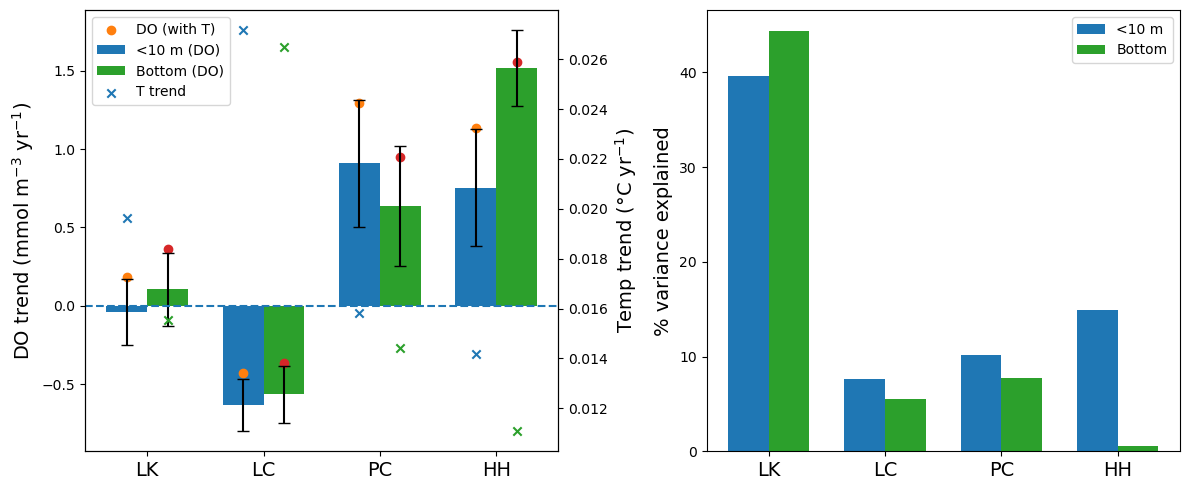

In [14]:
regions = trend_df["Region"].unique()
methods = ["<10 m", "Bottom"]
colors = {
    "<10 m": "tab:blue",
    "Bottom": "tab:green"
}
label_map = {
    "Liplip Kinney": "LK",
    "Lynch Cove": "LC",
    "Penn Cove": "PC",
    "Holmes Harbor": "HH"
}

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Trends with and without temperature
ax = axes[0]
ax2 = ax.twinx()

x = np.arange(len(regions))
width = 0.35


for i, method in enumerate(methods):

    df = (trend_df[trend_df["Method"] == method]
          .set_index("Region").loc[regions].reset_index())

    slopes = df["Slope (DO)"].values
    slopesT = df["Slope (T)"].values
    slopes_T = df["Slope (DO with T)"].values

    ci_low = df["CI low"].values
    ci_high = df["CI high"].values
    err = [slopes - ci_low, ci_high - slopes]

    ax.bar(x + i*width, slopes, width, yerr=err, capsize=4,
           label=f"{method} (DO)")

    ax.scatter(x + i*width, slopes_T, marker='o',
               label="DO (with T)" if i == 0 else None)

    ax2.scatter(x + i*width, slopesT, marker='x',
                color=colors[method],
                label="T trend" if i == 0 else None)

ax.axhline(0, linestyle='--')
ax.set_xticks(x + width/2)
ax.set_xticklabels([label_map[r] for r in regions], fontsize=14)
ax.set_ylabel("DO trend (mmol m$^{-3}$ yr$^{-1}$)", fontsize=14)
ax2.set_ylabel("Temp trend (°C yr$^{-1}$)", fontsize=14)

h1,l1 = ax.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2)

# temperature contribution to trends
ax = axes[1]

width = 0.35
x = np.arange(len(regions))

for i, method in enumerate(methods):

    df = (r2_df[r2_df["Method"] == method]
          .set_index("Region").loc[regions].reset_index())

    df_lag = (r2_lag_df[r2_lag_df["Method"] == method]
              .set_index("Region").loc[regions].reset_index())

    # original bars
    ax.bar(x + i*width, df["% explained by temp"],
           width, color=colors[method], label=f"{method}")

    # lagged temperature
    #ax.scatter(
    #    x + i*width,
    #    df_lag["% explained by temp (lag)"],
    #    color='red',
    #    marker='s',
    #    label="with lag" if i == 0 else None
    #)


ax.set_xticks(x + width/2)
ax.set_xticklabels([label_map[r] for r in regions], fontsize=14)
ax.set_ylabel("% variance explained", fontsize=14)
ax.legend()
#ax.grid(axis='y')

plt.tight_layout()
plt.show()

save_fig(fig, "Trend_and_Temperature_Contribution")

In [ ]:
drawdown_df.columns
trend_df.columns
r2_df.columns

combined_df = drawdown_df.merge(
    trend_df,
    on=["Region", "Method"],
    how="outer"
).merge(
    r2_df,
    on=["Region", "Method"],
    how="outer"
)

combined_df = combined_df[[
    "Region",
    "Method",
    "Mean slope",
    "Std",
    "N",
    "Slope (no T)",
    "CI low",
    "CI high",
    "p-value",
    "Slope (DO with T)",
    "CI low (T)",
    "CI high (T)",
    "R2 (time)",
    "R2 (time+temp)",
    "% explained by temp"
]]

combined_df.to_latex(
    "combined_DO_results.tex",
    index=False,
    float_format="%.3f",
    caption="Summary of seasonal drawdown, long-term trends, and temperature contribution for bottom and depth-averaged dissolved oxygen.",
    label="tab:combined_DO"
)

KeyError: "['Slope (no T)', 'p-value', 'Slope (with T)', 'CI low (T)', 'CI high (T)'] not in index"

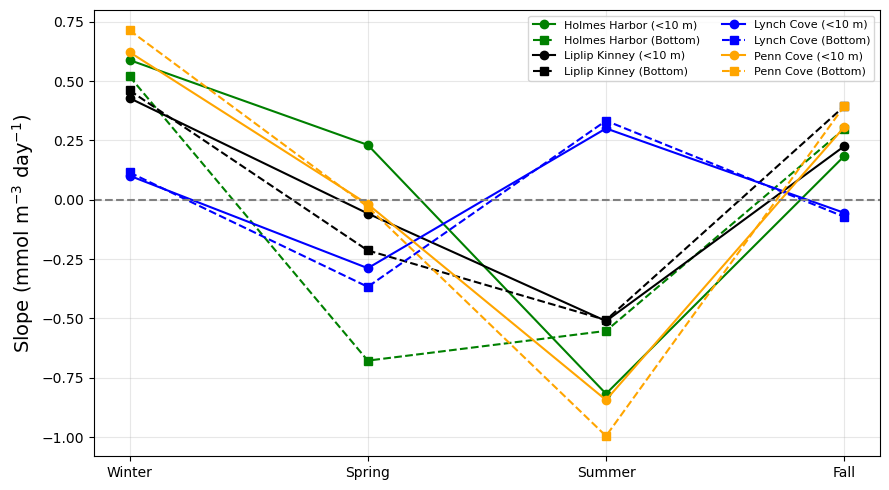

In [ ]:

seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11]
}

def compute_seasonal_drawdown(ts):

    results = []

    for season_name, months in seasons.items():

        slopes = []

        for year in range(2012, 2025):

            if season_name == "Winter":
                subset = ts[
                    ((ts.index.year == year-1) & (ts.index.month == 12)) |
                    ((ts.index.year == year) & (ts.index.month.isin([1, 2])))
                ]
            else:
                subset = ts[
                    (ts.index.year == year) &
                    (ts.index.month.isin(months))
                ]

            if len(subset) < 30:
                continue

            t = np.arange(len(subset))
            slope, _, _, _, _ = linregress(t, subset.values)

            slopes.append(slope)

        if len(slopes) > 0:
            results.append({
                "Season": season_name,
                "Mean slope": np.mean(slopes),
                "Std": np.std(slopes),
                "N": len(slopes)
            })

    return pd.DataFrame(results)


def build_seasonal_table(data, label):

    tables = []

    for r in data:
        df = compute_seasonal_drawdown(data[r])
        df["Region"] = r
        df["Method"] = label
        tables.append(df)

    return pd.concat(tables, ignore_index=True)


seasonal_df = pd.concat([
    build_seasonal_table(DO_deep, "<10 m"),
    build_seasonal_table(DO_bottom, "Bottom")
])

# reorder
seasonal_df = seasonal_df[["Region", "Method", "Season", "Mean slope", "Std", "N"]]

pivot_df = seasonal_df.pivot_table(
    index=["Region", "Method"],
    columns="Season",
    values="Mean slope"
)
season_order = ["Winter", "Spring", "Summer", "Fall"]
pivot_df = pivot_df.reindex(columns=season_order)

fig = plt.figure(figsize=(9,5))

markers = {
    "<10 m": "o",
    "Bottom": "s"
}

linestyles = {
    "<10 m": "-",
    "Bottom": "--"
}

colors = {
    "Liplip Kinney": "black",
    "Lynch Cove": "blue",
    "Penn Cove": "orange",
    "Holmes Harbor": "green"
}

for (region, method), row in pivot_df.iterrows():
    plt.plot(
        pivot_df.columns,
        row.values,
        marker=markers[method],
        linestyle=linestyles[method],
        color=colors[region],
        label=f"{region} ({method})"
    )
    

plt.axhline(0, linestyle='--', color='gray')

plt.ylabel("Slope (mmol m$^{-3}$ day$^{-1}$)", fontsize=14)

plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

save_fig(fig, "Seasonal_DO_change_Comparison")

seasonal_df.to_latex(
    "seasonal_drawdown_comparison.tex",
    index=False,
    float_format="%.3f",
    caption="Seasonal dissolved oxygen drawdown rates by region using bottom DO and DO below 10 m.",
    label="tab:seasonal_drawdown_comparison"
)

pivot_df.to_latex(
    "seasonal_drawdown_pivot.tex",
    float_format="%.3f",
    caption="Mean seasonal drawdown slopes (mmol m$^{-3}$ day$^{-1}$) by region and method.",
    label="tab:seasonal_drawdown_pivot"
)